In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [112]:
data=pd.read_csv(r"placement.csv")
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [113]:
data.shape

(200, 2)

In [114]:
data.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [115]:
from sklearn.model_selection import train_test_split

X=data.iloc[:,[0]]
y=data.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [116]:
X_train.shape,X_test.shape

((160, 1), (40, 1))

In [117]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [118]:
model.predict(X_test.iloc[[0]])

array([2.78031348])

In [119]:
y_pred=model.predict(X_test)

In [120]:
from sklearn.metrics import r2_score

score=r2_score(y_test,y_pred)
score

0.7730984312051673

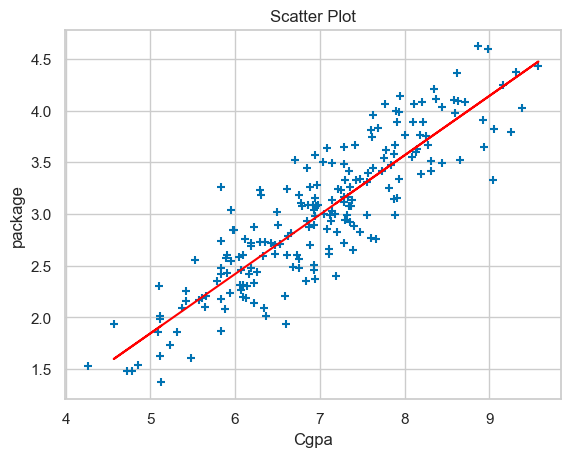

In [121]:
plt.style.use("seaborn-v0_8-colorblind")
plt.scatter(data['cgpa'],data['package'],marker="+")
plt.plot(X_train,model.predict(X_train),color="red")
plt.title("Scatter Plot")
plt.xlabel("Cgpa")
plt.ylabel("package")

plt.show()

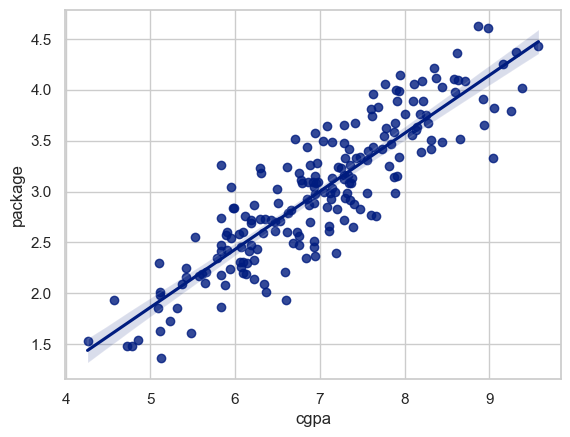

In [122]:
import seaborn as sns
# sns.set_context("notebook")
# sns.set_style('darkgrid')
# sns.set_palette("dark")
sns.set_theme(
    style="whitegrid",
    palette="dark",
    context="notebook"
)
sns.regplot(data=data,x='cgpa',y='package')
plt.show()

In [123]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))


In [124]:
from sklearn.preprocessing import StandardScaler

scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [125]:
y_pred=lr.predict(X_test)
score=r2_score(y_test,y_pred)
score

0.7730984312051673

In [126]:
from sklearn.linear_model import SGDRegressor

obj1=SGDRegressor(eta0=0.1,                
        max_iter=10000)

In [127]:
obj1.fit(X_train,y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",10000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [128]:
y_pred=obj1.predict(X_test)
score=r2_score(y_test,y_pred)
score

0.7779364499218103

In [129]:
import numpy as np

class MyLinearRegression():
    
    def __init__(self):
        self.m=None
        self.b=None

    def fit(self, X, y):
        X = np.array(X).ravel()   
        y = np.array(y)

        self.X_bar = np.mean(X)
        self.y_bar = np.mean(y)

        n = 0
        d = 0

        for xi, yi in zip(X, y):
            n += (xi - self.X_bar) * (yi - self.y_bar)
            d += (xi - self.X_bar) ** 2

        self.m = n / d
        self.b = self.y_bar - self.m * self.X_bar

        return self.m, self.b

    def predict(self, X):
        if self.m==None:
            return "Tranning is Not Performed!"
        X = np.array(X).ravel()   
        return self.m * X + self.b   

In [130]:
lr1=MyLinearRegression()
m,b=lr1.fit(X_train,y_train)
m,b

(np.float64(0.6242166826443954), np.float64(2.9958750000000007))

In [131]:
lr.coef_,lr.intercept_

(array([0.62421668]), np.float64(2.9958750000000007))

In [132]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [133]:
# MAE
mean_absolute_error(y_test,y_pred)

0.22794858293929643

In [134]:
# MSE
mean_squared_error(y_test,y_pred)

0.08238156605613509

In [135]:
# RMSE
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.28702189124896915)

In [136]:
r2=r2_score(y_test,y_pred)
r2

0.7779364499218103

In [137]:
n=X_test.shape[0]
k=X_test.shape[1]
adjasted_r2 = 1-(((1-r2)*(n-1))/(n-k-1))

In [138]:
adjasted_r2

0.7720926722881738

In [139]:
new_df1 = data.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.201600,3.26
1,5.12,0.932353,1.98
2,7.82,0.116137,3.25
3,7.42,0.623126,3.67
4,6.94,0.182460,3.57


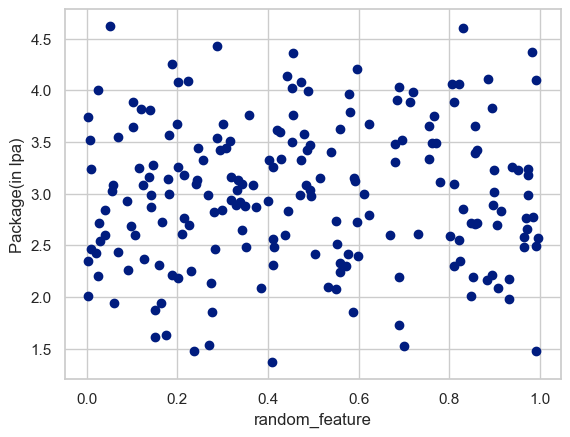

In [140]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')
plt.show()

In [141]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [142]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [143]:
lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7824482055359316


In [144]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7706886490784144